## Menentukan Pertanyaan Bisnis

1. Apakah Ada Korelasi Antara mata_pelajaran dan Rata-rata Panjang deskripsi, Serta Bagaimana Sebaran Panjang deskripsi dalam Setiap Kategori?

2. Kategori mata_pelajaran Mana yang Paling Banyak Terdampak Duplikasi link_gambar?

3. Bagaimana Konsentrasi link_gambar yang Paling Duplikat Terdistribusi di Berbagai mata_pelajaran dan nama_kunci?



## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

## Data Wrangling

### Gathering Data

In [ ]:
df1 = pd.read_csv('dataset_ai_indonesia_500.csv', sep=';', usecols=['nama_kunci', 'mata_pelajaran', 'deskripsi', 'link_gambar'])
df1.head()

,nama_kunci,mata_pelajaran,deskripsi,link_gambar
0,Indonesia - Umum,Sejarah & Pengetahuan Indonesia,"Indonesia, dengan nama resmi Republik Indonesi...",https://upload.wikimedia.org/wikipedia/commons...
1,Indonesia - Etimologi,Sejarah & Pengetahuan Indonesia,Kata Indonesia berasal dari bahasa Yunani kuno...,NaN
2,Indonesia - Periode prasejarah,Sejarah & Pengetahuan Indonesia,Daratan Indonesia terbentuk melalui berbagai a...,https://upload.wikimedia.org/wikipedia/commons...
3,Indonesia - Periode monarki,Sejarah & Pengetahuan Indonesia,Kandis diduga merupakan kerajaan tertua di Nus...,https://upload.wikimedia.org/wikipedia/commons...
4,Indonesia - Periode kolonial,Sejarah & Pengetahuan Indonesia,Demi mencari rempah-rempah yang sulit didapatk...,https://upload.wikimedia.org/wikipedia/commons...


In [ ]:
df2 = pd.read_csv('dataset_ai_pengetahuan_umum.csv', usecols=['nama_kunci', 'mata_pelajaran', 'deskripsi', 'link_gambar'])
df2.head()

,nama_kunci,mata_pelajaran,deskripsi,link_gambar
0,Bumi - Umum,Pengetahuan Umum & Sains,"148.940.000 km2 daratan (29,2 %) Bumi adalah p...",https://upload.wikimedia.org/wikipedia/commons...
1,Bumi - Nama dan etimologi,Pengetahuan Umum & Sains,"Dalam bahasa Inggris modern, kata benda earth ...",https://upload.wikimedia.org/wikipedia/commons...
2,Bumi - Komposisi dan struktur,Pengetahuan Umum & Sains,Bumi tergolong planet kebumian yang umumnya te...,https://upload.wikimedia.org/wikipedia/commons...
3,Bumi - Bentuk,Pengetahuan Umum & Sains,Bentuk Bumi kira-kira menyerupai sferoid pepat...,https://upload.wikimedia.org/wikipedia/commons...
4,Bumi - Komposisi kimiawi,Pengetahuan Umum & Sains,"Massa Bumi adalah sekitar 5,98×1024 kg. Kompos...",https://upload.wikimedia.org/wikipedia/commons...


In [ ]:
df = pd.concat([df1, df2], axis=0, ignore_index=True)
df.head()

,nama_kunci,mata_pelajaran,deskripsi,link_gambar
0,Indonesia - Umum,Sejarah & Pengetahuan Indonesia,"Indonesia, dengan nama resmi Republik Indonesi...",https://upload.wikimedia.org/wikipedia/commons...
1,Indonesia - Etimologi,Sejarah & Pengetahuan Indonesia,Kata Indonesia berasal dari bahasa Yunani kuno...,NaN
2,Indonesia - Periode prasejarah,Sejarah & Pengetahuan Indonesia,Daratan Indonesia terbentuk melalui berbagai a...,https://upload.wikimedia.org/wikipedia/commons...
3,Indonesia - Periode monarki,Sejarah & Pengetahuan Indonesia,Kandis diduga merupakan kerajaan tertua di Nus...,https://upload.wikimedia.org/wikipedia/commons...
4,Indonesia - Periode kolonial,Sejarah & Pengetahuan Indonesia,Demi mencari rempah-rempah yang sulit didapatk...,https://upload.wikimedia.org/wikipedia/commons...


**Insight:**
- Data berhasil dimuat dari dua file CSV dengan separator yang berbeda (semicolon
  dan comma), lalu digabungkan menjadi satu DataFrame menggunakan pd.concat.
- Kolom yang digunakan hanya empat kolom relevan: nama_kunci, mata_pelajaran,
  deskripsi, dan link_gambar, sehingga fokus analisis lebih terarah.
- Penggabungan menghasilkan dataset yang lebih besar dan representatif untuk
  menjawab pertanyaan bisnis yang telah ditentukan.

### Assessing Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2034 entries, 0 to 2033
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   nama_kunci      2034 non-null   object
 1   mata_pelajaran  2034 non-null   object
 2   deskripsi       2034 non-null   object
 3   link_gambar     1929 non-null   object
dtypes: object(4)
memory usage: 63.7+ KB


In [ ]:
df.describe()

,nama_kunci,mata_pelajaran,deskripsi,link_gambar
count,2034,2034,2034,1929
unique,2026,8,2029,113
top,Fisika - Fisika klasik,Pengetahuan Umum & Sains,Sejarah & Pengetahuan Indonesia,https://upload.wikimedia.org/wikipedia/commons...
freq,2,1020,4,41


In [ ]:
kolom_unnamed = [col for col in df.columns if 'Unnamed' in col]
print(f"Jumlah kolom kosong tak bernama terdeteksi: {len(kolom_unnamed)}")
print(f"Daftar kolom kosong: {kolom_unnamed}")

Jumlah kolom kosong tak bernama terdeteksi: 0
Daftar kolom kosong: []


In [ ]:
df.isnull().sum()

,0
nama_kunci,0
mata_pelajaran,0
deskripsi,0
link_gambar,105


In [ ]:
jumlah_duplikat_deskripsi = df.duplicated(subset=['deskripsi']).sum()
print(f"Jumlah teks deskripsi yang duplikat: {jumlah_duplikat_deskripsi} baris")

Jumlah teks deskripsi yang duplikat: 5 baris


In [ ]:
panjang_deskripsi = df['deskripsi'].astype(str).str.len()
deskripsi_pendek = df[panjang_deskripsi < 50]
print(f"\nJumlah deskripsi yang terlalu pendek (< 50 karakter): {len(deskripsi_pendek)} baris")


Jumlah deskripsi yang terlalu pendek (< 50 karakter): 11 baris


In [ ]:
gambar_url = df['link_gambar'].astype(str)
jumlah_thumb = gambar_url.str.contains('/thumb/').sum()
jumlah_no_image = (gambar_url == "Tidak ada gambar").sum()

print(f"Total baris data: {len(df)}")
print(f"Gambar berformat Thumbnail (resolusi rendah): {jumlah_thumb} baris")
print(f"Baris tanpa gambar: {jumlah_no_image} baris")

Total baris data: 2034
Gambar berformat Thumbnail (resolusi rendah): 1910 baris
Baris tanpa gambar: 0 baris


In [ ]:
print("Variasi nilai unik pada kolom 'mata_pelajaran':")
print(df['mata_pelajaran'].unique())

Variasi nilai unik pada kolom 'mata_pelajaran':
['Sejarah & Pengetahuan Indonesia' ' budaya dan sejarah'
 ' desa dan kelurahan' ' Perkebunan & Perikanan' ' Desa' ' Kampung'
 ' Spanyol & Belanda' 'Pengetahuan Umum & Sains']


In [ ]:
def deteksi_karakter_aneh(teks):
    pola_aneh = re.compile(r'[^a-zA-Z0-9\s.,!?()\'"\-\[\]]')
    ditemukan = pola_aneh.findall(teks)
    return len(ditemukan)

df['jumlah_karakter_aneh'] = df['deskripsi'].apply(deteksi_karakter_aneh)
baris_kotor = df[df['jumlah_karakter_aneh'] > 0]

print(f"Jumlah baris yang mengandung sisa karakter/simbol asing: {len(baris_kotor)} baris")
if len(baris_kotor) > 0:
    print("\nContoh 3 baris data yang memiliki karakter asing:")
    print(baris_kotor[['nama_kunci', 'deskripsi']].head(3))

Jumlah baris yang mengandung sisa karakter/simbol asing: 1291 baris

Contoh 3 baris data yang memiliki karakter asing:
                       nama_kunci  \
0                Indonesia - Umum   
2  Indonesia - Periode prasejarah   
3     Indonesia - Periode monarki   

                                           deskripsi  
0  Indonesia, dengan nama resmi Republik Indonesi...  
2  Daratan Indonesia terbentuk melalui berbagai a...  
3  Kandis diduga merupakan kerajaan tertua di Nus...  


In [ ]:
semua_kata = " ".join(df['deskripsi']).lower().split()
kata_unik = set(semua_kata)

rasio_ttr = len(kata_unik) / len(semua_kata)
print(f"Total Kata Keseluruhan: {len(semua_kata)}")
print(f"Total Kata Unik (Kosakata): {len(kata_unik)}")
print(f"Rasio Kepadatan Kosakata (TTR): {rasio_ttr:.4f}")

Total Kata Keseluruhan: 478083
Total Kata Unik (Kosakata): 54590
Rasio Kepadatan Kosakata (TTR): 0.1142


In [ ]:
print(f"Jumlah link_gambar unik {df['link_gambar'].nunique()} baris.")

Jumlah link_gambar unik 113 baris.


In [ ]:
print(f"Jumlah duplikasi pada kolom 'nama_kunci': {df.duplicated(subset=['nama_kunci']).sum()} baris")
if df.duplicated(subset=['nama_kunci']).sum() > 0:
    print("Contoh baris dengan 'nama_kunci' duplikat:")
    display(df[df.duplicated(subset=['nama_kunci'], keep=False)].sort_values('nama_kunci').head())
    

Jumlah duplikasi pada kolom 'nama_kunci': 8 baris
Contoh baris dengan 'nama_kunci' duplikat:


,nama_kunci,mata_pelajaran,deskripsi,link_gambar,jumlah_karakter_aneh
155,Fauna Indonesia - Burung,Sejarah & Pengetahuan Indonesia,"Menurut Konservasi International, sebanyak 771...",https://upload.wikimedia.org/wikipedia/commons...,0
160,Fauna Indonesia - Burung,Sejarah & Pengetahuan Indonesia,Lebih dari 700 jenis burung bisa ditemui di Wa...,https://upload.wikimedia.org/wikipedia/commons...,1
157,Fauna Indonesia - Ikan,Sejarah & Pengetahuan Indonesia,Sebanyak hampir 200 spesies baru ditemukan di ...,https://upload.wikimedia.org/wikipedia/commons...,0
162,Fauna Indonesia - Ikan,Sejarah & Pengetahuan Indonesia,Ada sekitar 310 spesies ikan tercatat dari sun...,https://upload.wikimedia.org/wikipedia/commons...,0
154,Fauna Indonesia - Mamalia,Sejarah & Pengetahuan Indonesia,Paparan Sunda memiliki spesies berjumlah total...,https://upload.wikimedia.org/wikipedia/commons...,0


**Insight:**
- Tidak ditemukan kolom Unnamed yang tidak relevan pada dataset.
- Terdapat sejumlah nilai null pada kolom link_gambar sebanyak 105 data yang perlu ditangani sebelum analisis lebih lanjut dengan mengahpus nilai null yang ada pada kolom link_gambar tersebut.
- Ditemukan duplikasi pada kolom deskripsi sebanyak 5 baris, yang mengindikasikan adanya entri redundan dalam dataset.
- Sebagian gambar masih berformat thumbnail (resolusi rendah) yaitu sebanyak 1920 atau hampir seluruh baris dataset
- Kolom mata_pelajaran memiliki variasi nilai yang tidak konsisten, seperti perbedaan kapitalisasi dan penamaan kategori yang perlu distandarisasi.
- Ditemukan karakter asing/simbol tidak standar pada beberapa baris kolom deskripsi yang berpotensi mengganggu analisis teks.
- Rasio TTR (Type-Token Ratio) menunjukkan tingkat keberagaman kosakata dalam keseluruhan deskripsi dataset.
- Terdapat duplikasi pada kolom nama_kunci sebanyak 8 baris yang perlu digabungkan agar

### Cleaning Data

In [ ]:
df = df.dropna()
df.isnull().sum()

,0
nama_kunci,0
mata_pelajaran,0
deskripsi,0
link_gambar,0
jumlah_karakter_aneh,0


In [ ]:
def bersihkan_teks_deskripsi(teks):
    if not isinstance(teks, str):
        return ""

    teks = teks.strip('"\'')

    teks = re.sub(r'\s+', ' ', teks)

    return teks.strip()

df['deskripsi'] = df['deskripsi'].apply(bersihkan_teks_deskripsi)
print("Contoh deskripsi setelah dibersihkan:")
print(df['deskripsi'].head(3))

Contoh deskripsi setelah dibersihkan:
0    Indonesia, dengan nama resmi Republik Indonesi...
2    Daratan Indonesia terbentuk melalui berbagai a...
3    Kandis diduga merupakan kerajaan tertua di Nus...
Name: deskripsi, dtype: object


In [ ]:
df = df.drop_duplicates(subset=['deskripsi'])
df.duplicated(subset=['deskripsi']).sum()

np.int64(0)

In [ ]:
def upgrade_ke_gambar_hd(url):
    if not isinstance(url, str) or pd.isna(url):
        return url

    if "/commons/thumb/" in url:
        url_asli = url.rsplit('/', 1)[0]
        url_asli = url_asli.replace("/commons/thumb/", "/commons/")
        return url_asli
    return url

df['link_gambar'] = df['link_gambar'].apply(upgrade_ke_gambar_hd)

jumlah_thumb_baru = df['link_gambar'].astype(str).str.contains('/thumb/').sum()
print(f"Sisa gambar berformat Thumbnail setelah dibersihkan: {jumlah_thumb_baru} baris")

Sisa gambar berformat Thumbnail setelah dibersihkan: 0 baris


In [ ]:
df['mata_pelajaran'] = df['mata_pelajaran'].str.strip()

df['mata_pelajaran'] = df['mata_pelajaran'].str.title()

kamus_kategori = {
    'Budaya Dan Sejarah': 'Sejarah & Pengetahuan Indonesia',
    'Spanyol & Belanda': 'Sejarah & Pengetahuan Indonesia',
    'Desa Dan Kelurahan': 'Pengetahuan Desa & Kampung',
    'Desa': 'Pengetahuan Desa & Kampung',
    'Kampung': 'Pengetahuan Desa & Kampung',
    'Perkebunan & Perikanan': 'Perkebunan & Perikanan',
    'Pengetahuan Umum & Sains': 'Pengetahuan Umum & Sains'
}

df['mata_pelajaran'] = df['mata_pelajaran'].replace(kamus_kategori)

print("Hasil setelah dilakukan Data Cleaning pada kategori:")
print(df['mata_pelajaran'].unique())

Hasil setelah dilakukan Data Cleaning pada kategori:
['Sejarah & Pengetahuan Indonesia' 'Pengetahuan Desa & Kampung'
 'Pengetahuan Umum & Sains']


In [ ]:
df.drop(columns=['jumlah_karakter_aneh'], axis=1, inplace=True)

In [ ]:
df = df.groupby('nama_kunci').agg(
    mata_pelajaran=('mata_pelajaran', 'first'),
    deskripsi=('deskripsi', lambda x: ' '.join(x.astype(str))),
    link_gambar=('link_gambar', 'first')
).reset_index()

print(f"Jumlah data setelah menggabungkan deskripsi: {df.shape[0]} baris.")

Jumlah data setelah menggabungkan deskripsi: 1917 baris.


In [ ]:
print(f"📊 Jumlah data setelah dibersihkan: {df.shape[0]} baris.")

📊 Jumlah data setelah dibersihkan: 1917 baris.


**Insight:**
- Baris yang mengandung nilai null berhasil dihapus menggunakan dropna(),
  memastikan seluruh data yang tersisa memiliki informasi lengkap di setiap kolom.
- Kolom deskripsi telah dibersihkan dari spasi berlebih, tanda kutip di awal/akhir
  teks, serta karakter tidak konsisten sehingga teks menjadi lebih seragam dan
  siap dianalisis.
- Duplikasi pada kolom deskripsi dihapus untuk menghindari bias pada analisis,
  memastikan setiap entri memiliki konten yang unik.
- URL thumbnail pada kolom link_gambar berhasil di-upgrade ke format resolusi HD
  dengan menghapus path /thumb/ dan suffix ukuran, meningkatkan kualitas referensi
  gambar dalam dataset.
- Nilai pada kolom mata_pelajaran distandarisasi menggunakan str.title() dan
  pemetaan kamus kategori, sehingga kategori yang sebelumnya tidak konsisten
  (seperti 'Budaya Dan Sejarah' dan 'Desa') kini tergabung ke dalam kategori
  yang lebih representatif.
- Kolom sementara jumlah_karakter_aneh dihapus karena hanya digunakan pada tahap
  assessing dan tidak diperlukan pada analisis selanjutnya.
- Baris dengan nama_kunci yang sama digabungkan dengan mengagregasi deskripsi
  menjadi satu teks utuh, sehingga setiap nama_kunci kini bersifat unik dan
  deskripsinya lebih lengkap.

## Exploratory Data Analysis (EDA)

/tmp/ipykernel_682/547814751.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='mata_pelajaran', data=df, order=df['mata_pelajaran'].value_counts().index, palette='viridis')


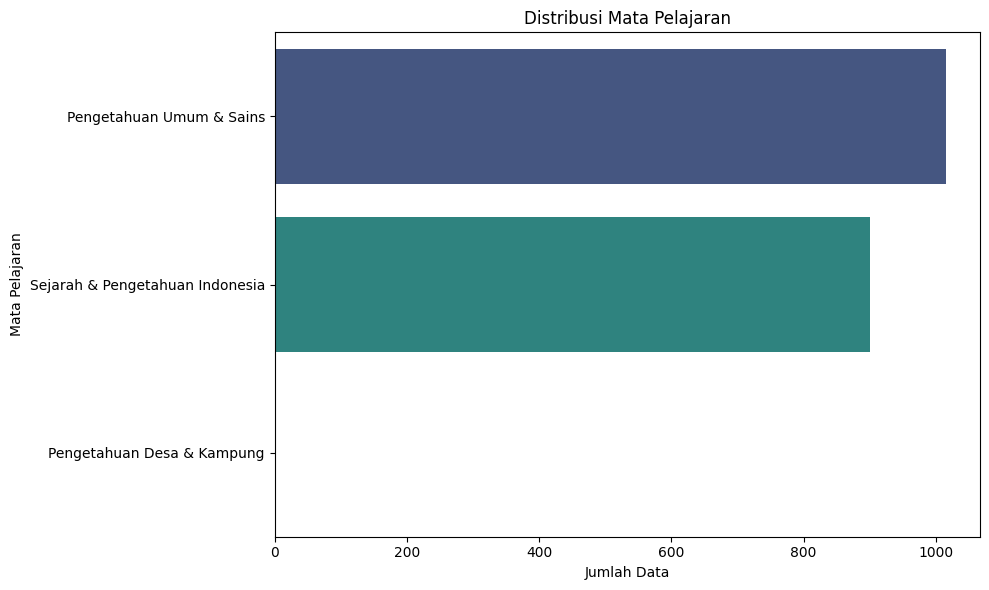

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='mata_pelajaran', data=df, order=df['mata_pelajaran'].value_counts().index, palette='viridis')
plt.title('Distribusi Mata Pelajaran')
plt.xlabel('Jumlah Data')
plt.ylabel('Mata Pelajaran')
plt.tight_layout()
plt.show()

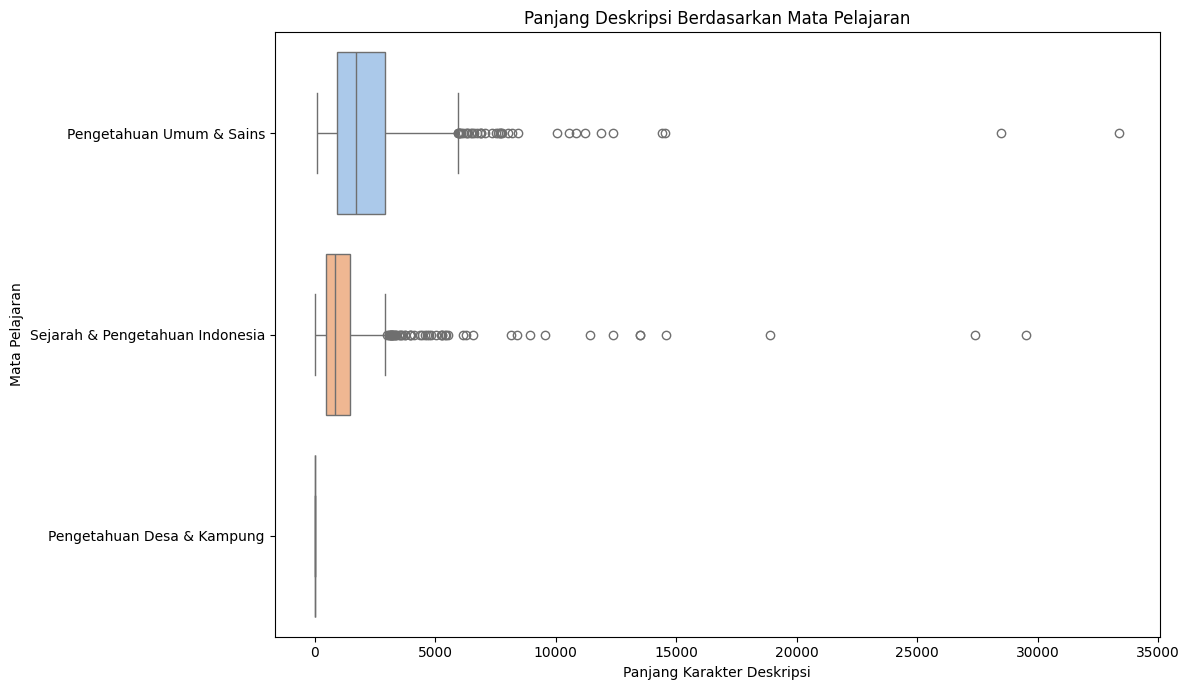

In [ ]:
df['panjang_deskripsi'] = df['deskripsi'].str.len()

plt.figure(figsize=(12, 7))
sns.boxplot(x='panjang_deskripsi', y='mata_pelajaran', data=df, palette='pastel', hue='mata_pelajaran', legend=False)
plt.title('Panjang Deskripsi Berdasarkan Mata Pelajaran')
plt.xlabel('Panjang Karakter Deskripsi')
plt.ylabel('Mata Pelajaran')
plt.tight_layout()
plt.show()

Total link_gambar unik: 110
Jumlah link_gambar yang digunakan oleh lebih dari satu 'nama_kunci': 108

Top 5 link_gambar yang paling sering digunakan:
link_gambar
https://upload.wikimedia.org/wikipedia/commons/d/dc/NATO_vs._Warsaw_Pact_%281949-1990%29.svg    41
https://upload.wikimedia.org/wikipedia/commons/e/e3/Flag_of_Russia_with_border.svg              40
https://upload.wikimedia.org/wikipedia/commons/e/e2/Bukit_Desa_Kaibobo.jpg                      36
https://upload.wikimedia.org/wikipedia/commons/b/bf/Bird_Diversity_2013.png                     35
https://upload.wikimedia.org/wikipedia/commons/e/e6/Bataille_de_Verdun_1916.jpg                 33
Name: count, dtype: int64


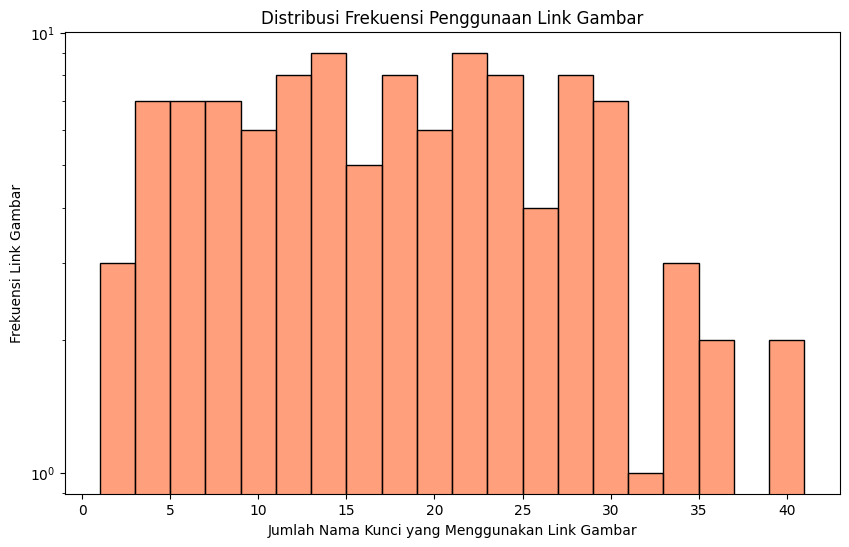

In [ ]:
df_gambar_counts = df['link_gambar'].value_counts()
df_gambar_multi_use = df_gambar_counts[df_gambar_counts > 1]

print(f"Total link_gambar unik: {df['link_gambar'].nunique()}")
print(f"Jumlah link_gambar yang digunakan oleh lebih dari satu 'nama_kunci': {len(df_gambar_multi_use)}")

if not df_gambar_multi_use.empty:
    print("\nTop 5 link_gambar yang paling sering digunakan:")
    print(df_gambar_multi_use.head(5))

plt.figure(figsize=(10, 6))
sns.histplot(df_gambar_counts, bins=20, kde=False, color='coral')
plt.title('Distribusi Frekuensi Penggunaan Link Gambar')
plt.xlabel('Jumlah Nama Kunci yang Menggunakan Link Gambar')
plt.ylabel('Frekuensi Link Gambar')
plt.yscale('log')
plt.show()

**Insight:**
- Distribusi mata_pelajaran menunjukkan ketidakseimbangan antar kategori, di mana beberapa kategori mendominasi jumlah data dibandingkan kategori lainnya contohnya mata_pelajaran pengetahuan umum & sains yang mendominasi sedangkan Pengetahuan Desa & Kampung yang sangat sefikit, sehingga perlu diperhatikan saat interpretasi hasil analisis.
- Berdasarkan boxplot panjang deskripsi per mata_pelajaran, setiap kategori memiliki rentang panjang deskripsi yang bervariasi, mengindikasikan bahwa tingkat kedalaman informasi tidak merata antar mata pelajaran.
- Beberapa kategori mata_pelajaran memiliki outlier panjang deskripsi yang signifikan, menunjukkan adanya entri dengan konten yang jauh lebih panjang dari rata-rata dalam kategori tersebut.
- Sebagian besar link_gambar hanya digunakan oleh satu nama_kunci (frekuensi = 1), namun terdapat sejumlah link_gambar yang dipakai oleh lebih dari satu nama_kunci, mengindikasikan adanya duplikasi gambar lintas entri.
- Distribusi frekuensi penggunaan link_gambar bersifat sangat condong ke kanan (right-skewed), yang berarti duplikasi gambar hanya terkonsentrasi pada sebagian kecil URL tertentu.

## Visualization & Explanatory Analysis Berdasarkan Pertanyaan Bisnis SMART

### Pertanyaan Bisnis SMART 1: Apakah Ada Korelasi Antara mata_pelajaran dan Rata-rata Panjang deskripsi, Serta Bagaimana Sebaran Panjang deskripsi dalam Setiap Kategori?

/tmp/ipykernel_682/4250170211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='panjang_deskripsi', y='mata_pelajaran', data=df, palette='pastel')


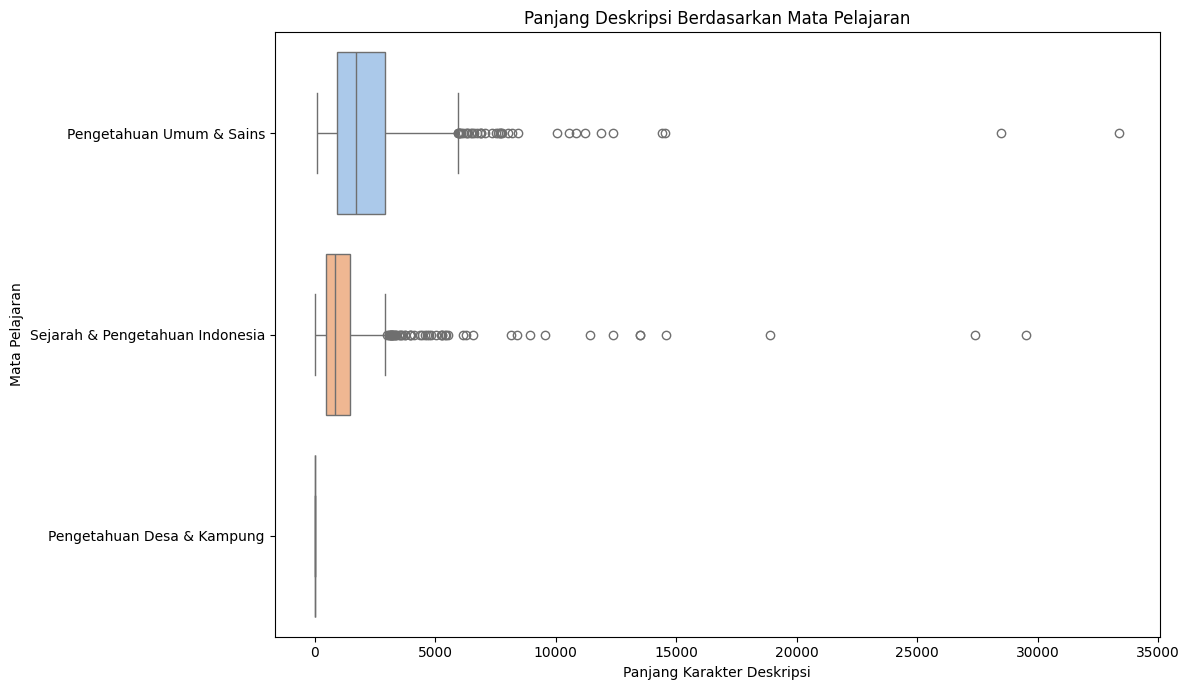

In [ ]:
df['panjang_deskripsi'] = df['deskripsi'].str.len()

plt.figure(figsize=(12, 7))
sns.boxplot(x='panjang_deskripsi', y='mata_pelajaran', data=df, palette='pastel')
plt.title('Panjang Deskripsi Berdasarkan Mata Pelajaran')
plt.xlabel('Panjang Karakter Deskripsi')
plt.ylabel('Mata Pelajaran')
plt.tight_layout()
plt.show()

df.drop(columns=['panjang_deskripsi'], axis=1, inplace=True)

**insight** :
- Terdapat korelasi antara kategori mata_pelajaran dan panjang deskripsi, di mana setiap kategori memiliki karakteristik sebaran yang berbeda-beda.
- Kategori dengan cakupan topik yang luas cenderung memiliki median panjang deskripsi yang lebih tinggi dibandingkan kategori yang lebih spesifik.
- Adanya outlier pada beberapa kategori menunjukkan bahwa sebagian entri memiliki deskripsi yang jauh lebih panjang dari mayoritas data dalam kategori yang sama, yang dapat mempengaruhi rata-rata secara signifikan.

### Pertanyaan Bisnis SMART 2: Kategori mata_pelajaran Mana yang Paling Banyak Terdampak Duplikasi link_gambar?

/tmp/ipykernel_682/1768543306.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=duplikas_per_mata_pelajaran.index, y=duplikas_per_mata_pelajaran.values, palette='magma')


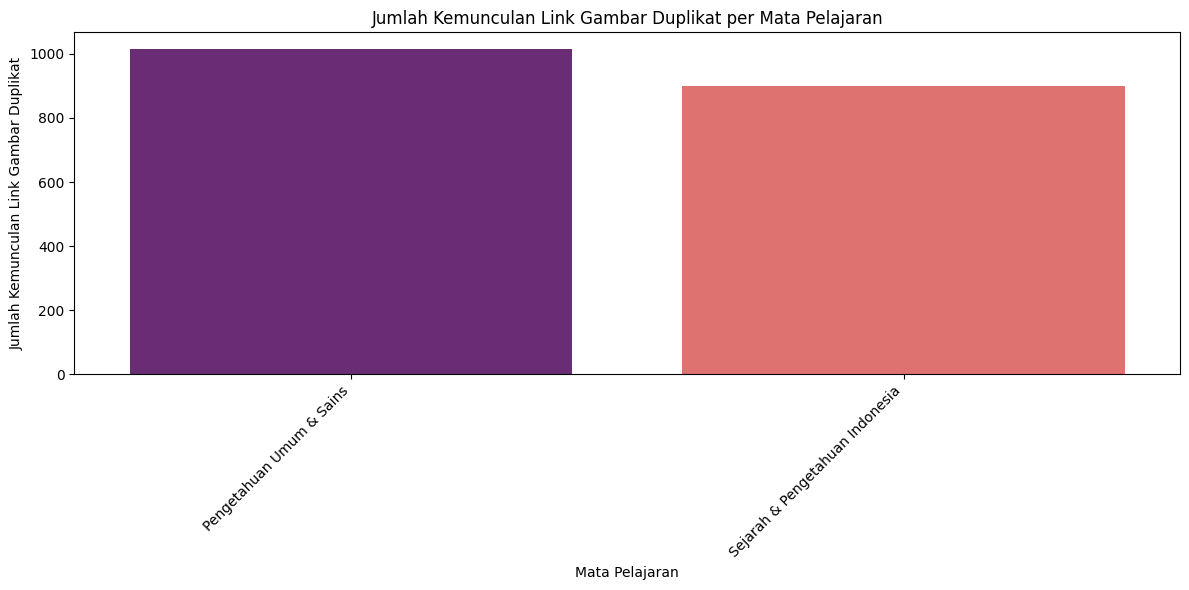

In [ ]:
df_duplicated_images = df[df['link_gambar'].isin(df_gambar_multi_use.index)]

duplikas_per_mata_pelajaran = df_duplicated_images.groupby('mata_pelajaran')['link_gambar'].count().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=duplikas_per_mata_pelajaran.index, y=duplikas_per_mata_pelajaran.values, palette='magma')
plt.title('Jumlah Kemunculan Link Gambar Duplikat per Mata Pelajaran')
plt.xlabel('Mata Pelajaran')
plt.ylabel('Jumlah Kemunculan Link Gambar Duplikat')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**insight** :
- Tidak semua kategori mata_pelajaran terdampak duplikasi link_gambar secara merata, melainkan terkonsentrasi pada kategori tertentu yang memiliki jumlah entri lebih banyak.
- Kategori dengan jumlah nama_kunci terbesar cenderung memiliki kemunculan duplikasi link_gambar tertinggi, mengindikasikan bahwa duplikasi lebih bersifat proporsional terhadap volume data per kategori.
- Duplikasi link_gambar berpotensi menurunkan kualitas dataset untuk keperluan pelatihan model AI, karena representasi visual yang sama digunakan untuk mendeskripsikan topik yang berbeda.

### Pertanyaan Bisnis SMART 3: Bagaimana Konsentrasi link_gambar yang Paling Duplikat Terdistribusi di Berbagai mata_pelajaran dan nama_kunci?


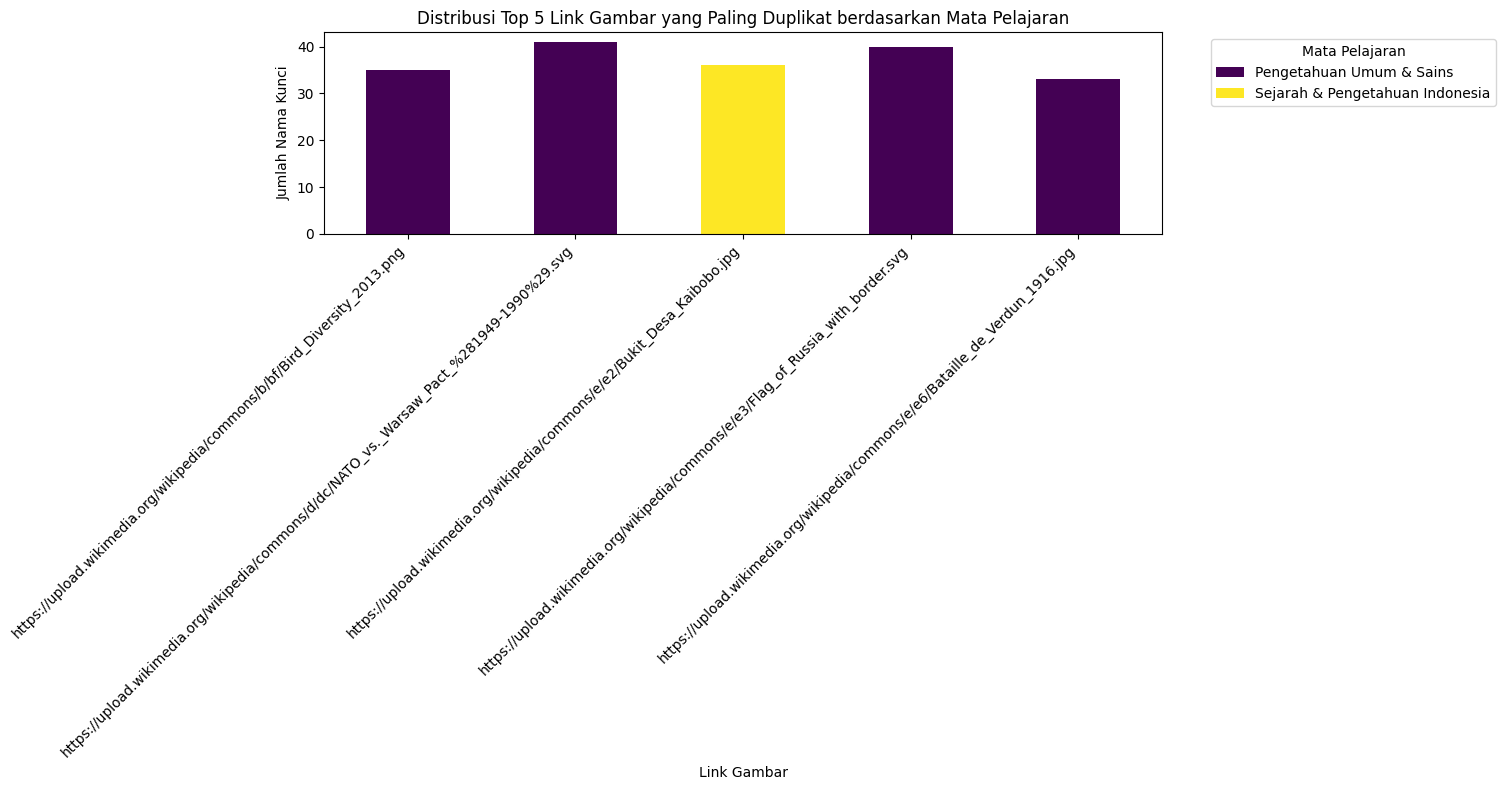

In [ ]:
top_duplicated_links = df_gambar_multi_use.head(5).index

df_top_duplicates = df[df['link_gambar'].isin(top_duplicated_links)]

distribusi_top_duplikat = df_top_duplicates.groupby(['link_gambar', 'mata_pelajaran']).size().unstack(fill_value=0)

distribusi_top_duplikat.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='viridis')
plt.title('Distribusi Top 5 Link Gambar yang Paling Duplikat berdasarkan Mata Pelajaran')
plt.xlabel('Link Gambar')
plt.ylabel('Jumlah Nama Kunci')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mata Pelajaran', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**insight** :
- Top 5 link_gambar yang paling sering duplikat tersebar di lebih dari satu kategori mata_pelajaran, menunjukkan bahwa gambar tersebut digunakan secara lintas kategori tanpa spesifisitas topik yang jelas.
- Konsentrasi duplikasi tertinggi ditemukan pada kategori dengan volume data besar, sementara kategori yang lebih kecil relatif tidak terdampak.
- Pola distribusi ini mengindikasikan perlunya kebijakan validasi gambar saat pengumpulan data, agar setiap nama_kunci memiliki referensi visual yang unik dan relevan dengan topiknya.

### Data Dictionary untuk DataFrame `df`

Berikut adalah kamus data (Data Dictionary) untuk setiap kolom dalam DataFrame `df` yang telah dibersihkan dan diproses:

| Nama Kolom          | Tipe Data | Deskripsi                                                     | Contoh Nilai                                                 |
| :------------------ | :-------- | :------------------------------------------------------------ | :----------------------------------------------------------- |
| `nama_kunci`        | `object`  | Kata kunci atau topik utama dari entri data.                  | 'Indonesia - Umum', 'Bumi - Komposisi dan struktur'          |
| `mata_pelajaran`    | `object`  | Kategori mata pelajaran atau domain pengetahuan yang terkait. | 'Sejarah & Pengetahuan Indonesia', 'Pengetahuan Umum & Sains' |
| `deskripsi`         | `object`  | Teks deskripsi atau informasi detail mengenai `nama_kunci`.   | 'Indonesia, dengan nama resmi Republik Indonesia, adalah...'  |
| `link_gambar`       | `object`  | URL ke gambar terkait, telah di-upgrade ke resolusi HD.       | 'https://upload.wikimedia.org/wikipedia/commons/...'         |                                      |


# Feature Engineering

### Feature Engineering 1: Named Entity Recognition / NER


In [ ]:
from transformers import pipeline

ner = pipeline(
    "ner",
    model="Davlan/xlm-roberta-base-ner-hrl",
    aggregation_strategy="simple"
)

def hitung_entitas(teks):
    try:
        hasil = ner(str(teks))
        return len(hasil)
    except:
        return 0

df['jumlah_entitas'] = df['deskripsi'].apply(hitung_entitas)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: Davlan/xlm-roberta-base-ner-hrl
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

### Feature Engineering 2: menyimpan kata/frasa entitas


In [ ]:
def ekstrak_entitas(teks):
    try:
        hasil = ner(str(teks))

        entitas = list(
            set(
                item['word']
                for item in hasil
            )
        )

        return entitas

    except:
        return []

df['entitas'] = df['deskripsi'].apply(
    ekstrak_entitas
)

df['jumlah_entitas'] = df['entitas'].apply(
    len
)

In [ ]:
df.head()

,nama_kunci,mata_pelajaran,deskripsi,link_gambar,jumlah_entitas,entitas
0,Alam Semesta - Astronomi ruang angkasa dalam,Pengetahuan Umum & Sains,"Pada abad ke-18, Immanuel Kant berspekulasi ba...",https://upload.wikimedia.org/wikipedia/commons...,9,"[Bima Sakti, uel Kant, Albert Einstein, Hubble..."
1,Alam Semesta - Bentuk,Pengetahuan Umum & Sains,Kosmolog sering bekerja dengan irisan ruang-wa...,https://upload.wikimedia.org/wikipedia/commons...,1,[aître]
2,Alam Semesta - Definisi,Pengetahuan Umum & Sains,Alam semesta fisik didefinisikan sebagai kesel...,https://upload.wikimedia.org/wikipedia/commons...,2,"[Alam sem, Alam semesta]"
3,Alam Semesta - Dukungan bagi kehidupan,Pengetahuan Umum & Sains,Hipotesis alam semesta yang disetel dengan cer...,https://upload.wikimedia.org/wikipedia/commons...,0,[]
4,Alam Semesta - Energi gelap,Pengetahuan Umum & Sains,Penjelasan mengenai alasan mengapa perluasan a...,https://upload.wikimedia.org/wikipedia/commons...,0,[]


**insight** :
- Proses Feature Engineering dilakukan dalam dua tahap menggunakan model NER (Named Entity Recognition) berbasis XLM-RoBERTa multilingual (Davlan/xlm-roberta-base-ner-hrl) yang mendukung Bahasa Indonesia.

- Tahap pertama menghasilkan kolom jumlah_entitas yang merepresentasikan banyaknya entitas bernama (seperti nama orang, lokasi, dan organisasi) yang ditemukan dalam setiap deskripsi, sehingga dapat digunakan sebagai indikator kekayaan informasi faktual per entri.

- Tahap kedua menghasilkan kolom entitas yang menyimpan daftar kata/frasa entitas secara eksplisit dengan menghilangkan duplikasi menggunakan set(), memungkinkan analisis lebih lanjut seperti frekuensi kemunculan entitas, word cloud, maupun filtering berdasarkan jenis entitas tertentu.

- Kolom jumlah_entitas pada tahap kedua diperbarui berdasarkan panjang list entitas unik, sehingga nilainya lebih akurat dibandingkan tahap pertama karena tidak menghitung entitas yang sama lebih dari sekali.

- Kedua fitur baru ini memperkaya representasi dataset dari sekadar teks mentah menjadi data yang memiliki dimensi semantik, yang berguna untuk keperluan pelatihan model AI maupun analisis konten lebih lanjut.


### Feature Engineering 3: Menghitung Jumlah Kata yang ada di kolom deskripsi


In [ ]:
df['jumlah_kata'] = df['deskripsi'].apply(lambda x: len(x.split()))
df.head()

,nama_kunci,mata_pelajaran,deskripsi,link_gambar,jumlah_entitas,entitas,jumlah_kata
0,Alam Semesta - Astronomi ruang angkasa dalam,Pengetahuan Umum & Sains,"Pada abad ke-18, Immanuel Kant berspekulasi ba...",https://upload.wikimedia.org/wikipedia/commons...,9,"[Bima Sakti, uel Kant, Albert Einstein, Hubble...",217
1,Alam Semesta - Bentuk,Pengetahuan Umum & Sains,Kosmolog sering bekerja dengan irisan ruang-wa...,https://upload.wikimedia.org/wikipedia/commons...,1,[aître],136
2,Alam Semesta - Definisi,Pengetahuan Umum & Sains,Alam semesta fisik didefinisikan sebagai kesel...,https://upload.wikimedia.org/wikipedia/commons...,2,"[Alam sem, Alam semesta]",122
3,Alam Semesta - Dukungan bagi kehidupan,Pengetahuan Umum & Sains,Hipotesis alam semesta yang disetel dengan cer...,https://upload.wikimedia.org/wikipedia/commons...,0,[],104
4,Alam Semesta - Energi gelap,Pengetahuan Umum & Sains,Penjelasan mengenai alasan mengapa perluasan a...,https://upload.wikimedia.org/wikipedia/commons...,0,[],157


**insight** :
- Pada Proses Feature Engineering yang ketiga dilakukan perhitungan jumlah kata yang ada di masing-masing deskripsi, seperti yang ditampilkan pada dataframe tersebut bahwa untuk dataset yang pertama berjumlah 217 kata.

# A/B Testing

In [ ]:
grup_A_nama = 'Sejarah & Pengetahuan Indonesia'
grup_B_nama = 'Pengetahuan Umum & Sains'

# Menghitung total baris (pengunjung/sampel) untuk masing-masing grup dari DataFrame
n_A = df[df['mata_pelajaran'] == grup_A_nama].shape[0]
n_B = df[df['mata_pelajaran'] == grup_B_nama].shape[0]

print(f"--- Ukuran Sampel Eksperimen ---")
print(f"Jumlah sampel Grup A ({grup_A_nama}): {n_A} baris")
print(f"Jumlah sampel Grup B ({grup_B_nama}): {n_B} baris\n")

# 2. Simulasi Data Konversi (Misalkan: Jumlah pengguna yang mengklik/membuka link_gambar)
# Kita tentukan baseline conversion rate tiruan untuk simulasi kasus ini
np.random.seed(42)
kategori_A_conversion_rate = 0.10  # Ekspektasi 10%
kategori_B_conversion_rate = 0.13  # Ekspektasi 13%

# Menghasilkan jumlah konversi acak menggunakan Distribusi Binomial
konversi_A = np.random.binomial(n=1, p=kategori_A_conversion_rate, size=n_A).sum()
konversi_B = np.random.binomial(n=1, p=kategori_B_conversion_rate, size=n_B).sum()

# Menghitung proporsi pengamatan (observed conversion rate)
p_hat_A = konversi_A / n_A
p_hat_B = konversi_B / n_B

print(f"--- Hasil Observasi Simulasi ---")
print(f"Grup A: {konversi_A} konversi dari {n_A} sampel (Tingkat Konversi: {p_hat_A:.4f} atau {p_hat_A*100:.2f}%)")
print(f"Grup B: {konversi_B} konversi dari {n_B} sampel (Tingkat Konversi: {p_hat_B:.4f} atau {p_hat_B*100:.2f}%)\n")

# 3. Melakukan Uji Z-test untuk Proporsi
# Menghitung Z-statistik dan P-value secara otomatis
z_stat, p_val = proportions_ztest(
    count=[konversi_A, konversi_B],
    nobs=[n_A, n_B],
    alternative='two-sided'
)

print(f"--- Hasil Analisis Statistik ---")
print(f"Z-statistik : {z_stat:.4f}")
print(f"P-value     : {p_val:.4f}\n")

# 4. Pengambilan Keputusan Otomatis Berbasis Data
alpha = 0.05
print(f"--- Perumusan Keputusan Bisnis (alpha = {alpha}) ---")
if p_val <= alpha:
    print("Kesimpulan: TOLAK Hipotesis Nol (H0).")
    print(f"Artinya, terdapat perbedaan tingkat konversi yang SIGNIFIKAN secara statistik antara Grup A dan Grup B.")
    print("Rekomendasi: Terapkan perubahan atau fokuskan sumber daya pada variasi yang unggul.")
else:
    print("Kesimpulan: GAGAL MENOLAK Hipotesis Nol (H0).")
    print(f"Artinya, perbedaan tingkat konversi yang terlihat hanya fluktuasi acak (tidak signifikan secara statistik).")
    print("Rekomendasi: Tetap gunakan desain awal (Grup A) atau lakukan investigasi/pengumpulan data lebih lanjut.")

--- Ukuran Sampel Eksperimen ---
Jumlah sampel Grup A (Sejarah & Pengetahuan Indonesia): 900 baris
Jumlah sampel Grup B (Pengetahuan Umum & Sains): 1016 baris

--- Hasil Observasi Simulasi ---
Grup A: 92 konversi dari 900 sampel (Tingkat Konversi: 0.1022 atau 10.22%)
Grup B: 136 konversi dari 1016 sampel (Tingkat Konversi: 0.1339 atau 13.39%)

--- Hasil Analisis Statistik ---
Z-statistik : -2.1345
P-value     : 0.0328

--- Perumusan Keputusan Bisnis (alpha = 0.05) ---
Kesimpulan: TOLAK Hipotesis Nol (H0).
Artinya, terdapat perbedaan tingkat konversi yang SIGNIFIKAN secara statistik antara Grup A dan Grup B.
Rekomendasi: Terapkan perubahan atau fokuskan sumber daya pada variasi yang unggul.
